# 🇬🇧 UK Business Landscape: Industry Mapping & Spatial Analysis
*Analyzing geographic distribution of UK companies by SIC code using postcode extraction and spatial visualization*

**Dataset:** All UK Active Companies By SIC And Geolocated (Kaggle)  
**Source:** Companies House (UK Gov Registry, 2017 snapshot)  
**Fields:** CompanyNumber, IncorporationDate, RegAddressPostCode, Latitude, Longitude, SIC

Objectives:
1. Validate postcode format and assign regions (London vs Rest-of-UK)
2. Visualize national business density using latitude/longitude coordinates
3. Compare industry distribution between London and Rest-of-UK using SIC codes
4. Enrich dataset with official SIC 2007 descriptions and export cleaned version

## 1. Data Loading & Initial QA

In [1]:
import pandas as pd

# Load dataset with low_memory=False to handle mixed types in large file
companies = pd.read_csv('AllCompanies2.csv/AllCompanies2.csv', low_memory=False)

In [2]:
# Initial quality checks: shape, data types, missing values

print(f'Shape: {companies.shape}')
print('\n' + '=' * 50)
print('Data types:')
print(companies.dtypes)
print('\n' + '=' * 50)
print('Missing values:')
print(companies.isnull().sum())
print('\n' + '=' * 50)
print('Preview first 5 rows:')
companies.head()

Shape: (3801732, 6)

Data types:
CompanyNumber             str
IncorporationDate         str
RegAddressPostCode        str
Latitude              float64
Longitude             float64
SIC                   float64
dtype: object

Missing values:
CompanyNumber             0
IncorporationDate         0
RegAddressPostCode        0
Latitude                  0
Longitude                 0
SIC                   96817
dtype: int64

Preview first 5 rows:


,CompanyNumber,IncorporationDate,RegAddressPostCode,Latitude,Longitude,SIC
0,SC503243,14/4/2015,AB10 1AB,57.149606,-2.096916,99999.0
1,SO305648,21/3/2016,AB10 1AB,57.149606,-2.096916,NaN
2,SC481537,7/7/2014,AB10 1AU,57.147711,-2.096432,9100.0
3,SC265933,2/4/2004,AB10 1AU,57.147711,-2.096432,41100.0
4,SC541045,25/7/2016,AB10 1AU,57.147711,-2.096432,56101.0


## 2. Postcode Validation & Region Assignment

In [3]:
# Validate UK postcode format
uk_postcode_pattern = r'^[A-Z]{1,2}\d[A-Z\d]? \d[A-Z]{2}$'
companies['Postcode_Valid'] = companies['RegAddressPostCode'].str.match(uk_postcode_pattern, na=False)

# Assign Region: London vs Rest of UK
london_areas = {'E', 'EC', 'N', 'NW', 'SE', 'SW', 'W', 'WC'}

def assign_region(postcode):
    if pd.isna(postcode): 
        return 'Unknown'
    outcode = postcode.split()[0]  # e.g., "SW1A"
    
    # Extract area prefix (letters before first digit)
    prefix = ''
    for char in outcode:
        if char.isalpha():
            prefix += char
        else:
            break
            
    return 'London' if prefix in london_areas else 'Rest of UK'

companies['Region'] = companies['RegAddressPostCode'].apply(assign_region)

# Verification
print(f"✅ Valid postcodes: {companies['Postcode_Valid'].sum():,} ({companies['Postcode_Valid'].mean()*100:.2f}%)")
print("\nRegion distribution:")
print(companies['Region'].value_counts().to_markdown())

✅ Valid postcodes: 3,801,033 (99.98%)

Region distribution:
| Region     |   count |
|:-----------|--------:|
| Rest of UK | 3051061 |
| London     |  750671 |


📍 Postcode validation & region assignment: Applied regex for format check and extracted area prefixes to classify London vs Rest-of-UK.

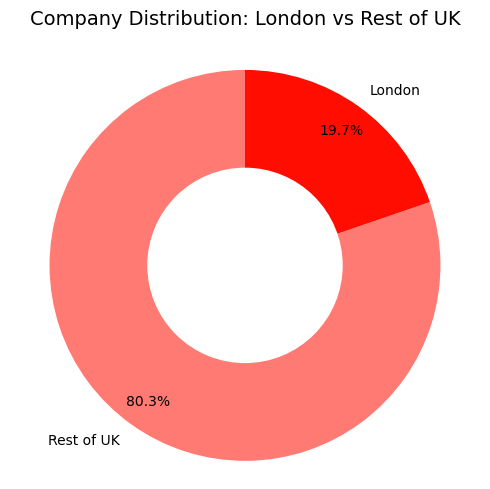

In [4]:
# Donut chart
region_counts = companies['Region'].value_counts()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

wedges, texts, autotexts = ax.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#FF7A73', '#FF0D00'],
    pctdistance=0.85,
    textprops={'fontsize': 10}
)

# Draw donut style
centre_circle = plt.Circle((0,0), 0.5, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Company Distribution: London vs Rest of UK', fontsize=14, pad=20)
ax.axis('equal')

plt.tight_layout()
plt.show()

🍩 Region split visualization: Donut chart showing ~20% of companies registered in London vs ~80% in Rest of UK.

## 3. SIC Code Analysis & Industry Mapping

### SIC Code Distribution Analysis

In [5]:
# Unique SIC codes and missing values
print(f"Missing SIC values: {companies['SIC'].isna().sum()}")
print(f"\nUnique SIC codes: {companies['SIC'].nunique()}")
print("\nTop 5 SIC codes:")
print(companies['SIC'].value_counts().head())

Missing SIC values: 96817

Unique SIC codes: 990

Top 5 SIC codes:
SIC
82990.0    275729
70229.0    168656
99999.0    158690
96090.0    125480
62020.0    125219
Name: count, dtype: int64


📊 990 unique SIC codes across \~3.8M companies; 96.8K missing values (~2.5%) retained for geographic analysis.

In [6]:
# Load official UK SIC 2007 reference
sic_ref = pd.read_csv('SIC07_CH_condensed_list_en.csv')
print(f"Reference shape: {sic_ref.shape}")
sic_ref.head(3)

Reference shape: (731, 2)


,SIC Code,Description
0,1110,"Growing of cereals (except rice), leguminous c..."
1,1120,Growing of rice
2,1130,"Growing of vegetables and melons, roots and tu..."


📂 Loaded official UK SIC 2007 condensed reference (gov.uk) with SIC Code and Description columns.

In [7]:
# Align types for reliable mapping
sic_ref['SIC Code'] = sic_ref['SIC Code'].astype('float64')
print(f"sic_ref['SIC Code'] dtype: {sic_ref['SIC Code'].dtype}")
print(f"companies['SIC'] dtype: {companies['SIC'].dtype}")

sic_ref['SIC Code'] dtype: float64
companies['SIC'] dtype: float64


🔧 Converted SIC Code to float64 to match companies['SIC'] dtype for reliable mapping.

In [8]:
# Check how many dataset codes exist in reference
valid_codes = sic_ref['SIC Code'].unique()
matched = companies['SIC'].isin(valid_codes).sum()
total = companies['SIC'].notna().sum()
print(f"Matched: {matched:,} out of {total:,} ({matched/total*100:.1f}%)")

Matched: 3,702,538 out of 3,704,915 (99.9%)


✅ 99.9% of SIC codes in dataset match the official reference — ready for mapping.

In [9]:
# Inspect unmatched codes
unmatched = companies.loc[~companies['SIC'].isin(valid_codes), 'SIC'].dropna()
if not unmatched.empty:
    print(f"Unmatched: {len(unmatched):,} records ({len(unmatched)/len(companies)*100:.2f}%)")
    print(unmatched.value_counts().head())

Unmatched: 2,377 records (0.06%)
SIC
7499.0    472
4521.0    166
7011.0    162
7487.0    137
5010.0     84
Name: count, dtype: int64


🔍 2,377 records (0.06%) unmatched — predominantly 4-digit parent codes vs. 5-digit reference codes.

### Industry Mapping

In [10]:
# Create mapping and apply
sic_mapping = dict(zip(sic_ref['SIC Code'], sic_ref['Description']))
companies['Industry'] = companies['SIC'].map(sic_mapping)

# Handle data quality cases explicitly
is_unmatched = companies['SIC'].notna() & companies['Industry'].isna()
companies.loc[is_unmatched, 'Industry'] = 'Other / Unmatched SIC'
companies.loc[companies['SIC'].isna(), 'Industry'] = 'Missing SIC'

🔄 Applied SIC→Industry mapping; separated Missing SIC from Unmatched SIC for analytical transparency.

In [11]:
# Verify label distribution
print("Industry value counts (top 5):")
print(companies['Industry'].value_counts().head())
print(f"\nMissing SIC: {(companies['Industry']=='Missing SIC').sum():,}")
print(f"Unmatched SIC: {(companies['Industry']=='Other / Unmatched SIC').sum():,}")

Industry value counts (top 5):
Industry
Other business support service activities n.e.c.                     275729
Management consultancy activities other than financial management    168656
Dormant Company                                                      158690
Other service activities n.e.c.                                      125480
Information technology consultancy activities                        125219
Name: count, dtype: int64

Missing SIC: 96,817
Unmatched SIC: 2,377


✅ Industry column created: ~97.4% mapped to official descriptions, 2.5% Missing SIC, 0.06% Unmatched.

In [12]:
# Save enriched dataset
companies.to_csv('companies_with_industry.csv', index=False)
print(f"Saved columns: {companies.columns.tolist()}")

Saved columns: ['CompanyNumber', 'IncorporationDate', 'RegAddressPostCode', 'Latitude', 'Longitude', 'SIC', 'Postcode_Valid', 'Region', 'Industry']


💾 Exported companies_with_industry.csv with Industry column for downstream analysis.

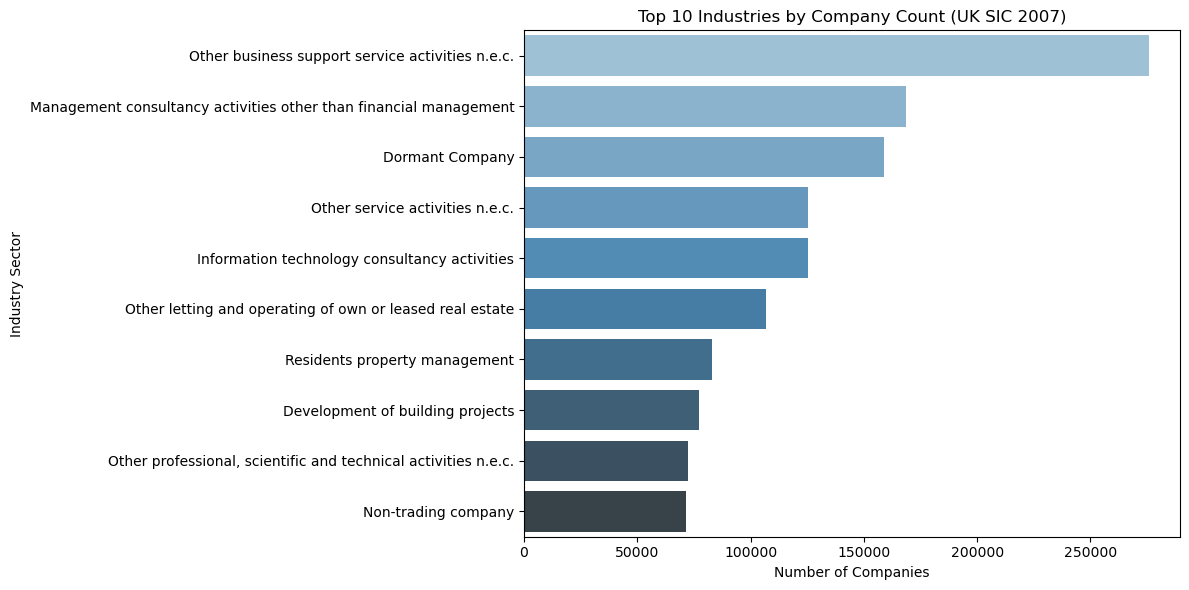

In [13]:
# Horizontal bar chart of top industries
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out data quality labels for clean visualization
industries_clean = companies[
    ~companies['Industry'].isin(['Missing SIC', 'Other / Unmatched SIC'])
]['Industry']

# Get top-10 industries
top_10 = industries_clean.value_counts().head(10)

# Create horizontal bar chart (
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10.values, 
    y=top_10.index, 
    hue=top_10.index,      
    palette='Blues_d', 
    legend=False           
)

# Labels and title
plt.xlabel('Number of Companies')
plt.ylabel('Industry Sector')
plt.title('Top 10 Industries by Company Count (UK SIC 2007)')
plt.tight_layout()
plt.show()

📊 Horizontal bar chart of top-10 SIC 2007 sectors (excluding data quality labels).

## 4. Spatial Visualization: Business Density

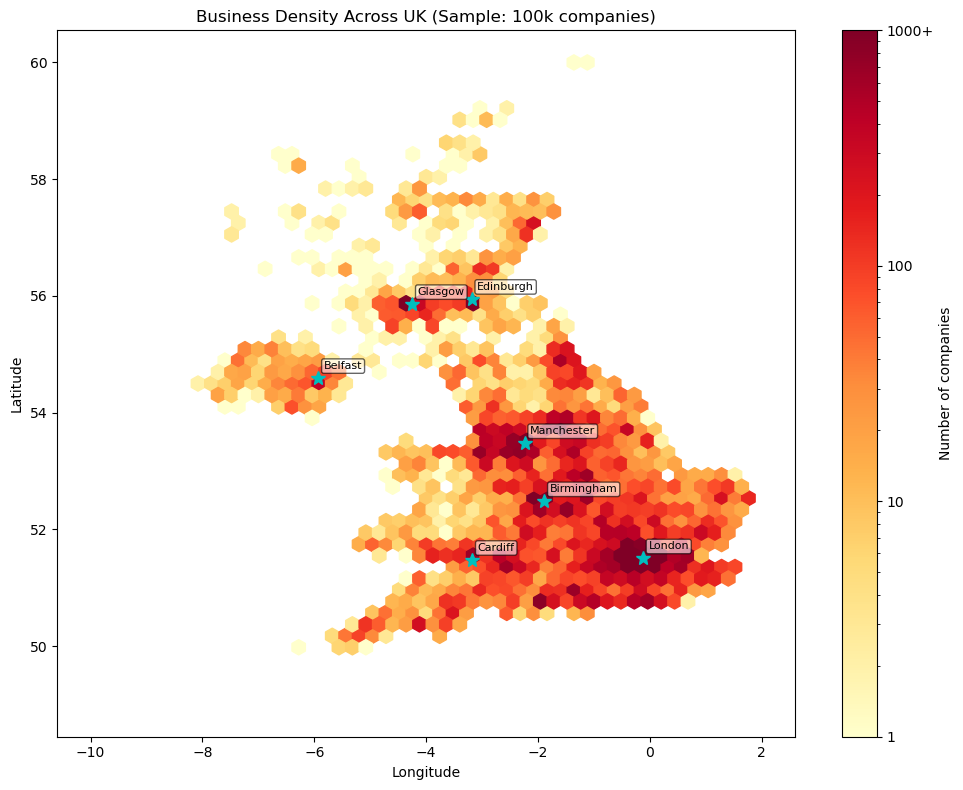

In [14]:
# Spatial visualization: business density across UK
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Sample 100k points for fast rendering
sample = companies.dropna(subset=['Latitude', 'Longitude']).sample(n=100_000, random_state=42)

# Hexbin plot: shows density hotspots
plt.figure(figsize=(10, 8))

hb = plt.hexbin(
    sample['Longitude'], sample['Latitude'],
    gridsize=50, cmap='YlOrRd', mincnt=1,
    extent=[-10, 2, 49, 60],  # UK bounding box
    norm=LogNorm(vmin=1, vmax=1000)
)

# # Add city markers and labels
cities = {
    'London': (-0.1278, 51.5074),
    'Birmingham': (-1.8904, 52.4862),
    'Manchester': (-2.2426, 53.4808),
    'Edinburgh': (-3.1883, 55.9533),
    'Glasgow': (-4.2518, 55.8642),
    'Cardiff': (-3.1791, 51.4816),
    'Belfast': (-5.9301, 54.5973)
}

for city, (lon, lat) in cities.items():
    plt.plot(lon, lat, 'c*', markersize=10)
    plt.text(lon + 0.1, lat + 0.15, city, fontsize=8, 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))


cbar = plt.colorbar(hb, label='Number of companies')
cbar.set_ticks([1, 10, 100, 1000])
cbar.set_ticklabels(['1', '10', '100', '1000+'])

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Business Density Across UK (Sample: 100k companies)')
plt.tight_layout()
plt.show()

🗺️ Business density visualization: Hexbin plot with logarithmic scale reveals major UK business hubs (London, Manchester, Birmingham, Glasgow) while preserving visibility of smaller regional clusters.

## 5. Regional Comparison: London vs Rest-of-UK

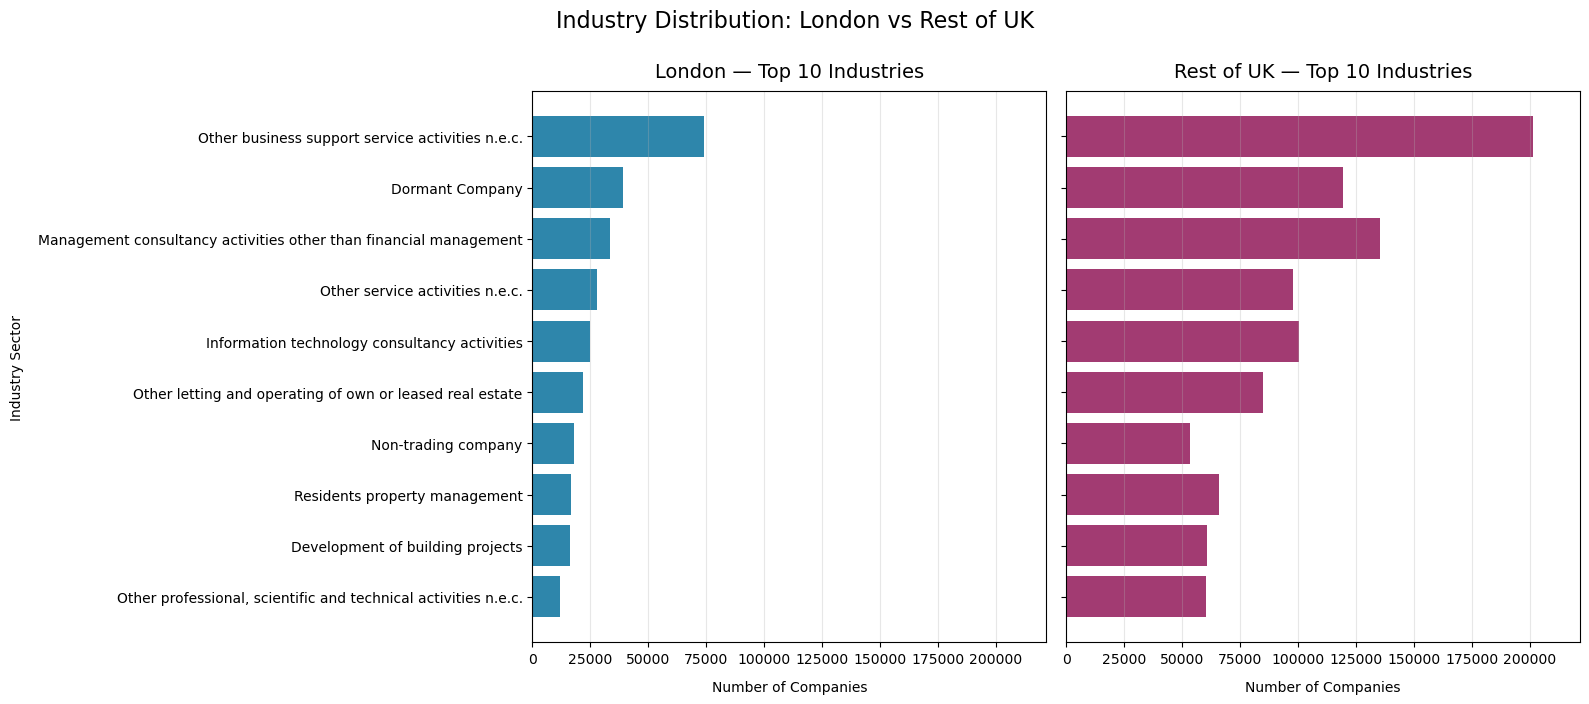

In [15]:
# Compare top industries: London vs Rest of UK
import matplotlib.pyplot as plt
import seaborn as sns

# Filter valid industries and group by region
valid_industries = ~companies['Industry'].isin(['Missing SIC', 'Other / Unmatched SIC'])
comparison = companies[valid_industries].groupby('Region')['Industry'].value_counts().unstack(fill_value=0)

# Get top-10 industries by total count (UK-wide)
top_10_uk = companies[valid_industries]['Industry'].value_counts().head(10).index

# Calculate max value to set uniform x-axis scale (with 10% padding)
max_val = comparison.loc[['London', 'Rest of UK'], top_10_uk].max().max() * 1.1

# Plot side-by-side horizontal bars
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for idx, region in enumerate(['London', 'Rest of UK']):
    data = comparison.loc[region, top_10_uk].sort_values()
    axes[idx].barh(data.index, data.values, color=['#2E86AB', '#A23B72'][idx])
    axes[idx].set_xlabel('Number of Companies', labelpad=10)
    axes[idx].set_title(f'{region} — Top 10 Industries', fontsize=14, pad=10)
    axes[idx].grid(axis='x', alpha=0.3)

    # Set uniform x-axis limit for fair comparison
    axes[idx].set_xlim(0, max_val)
    
axes[0].set_ylabel('Industry Sector', labelpad=10)
plt.suptitle('Industry Distribution: London vs Rest of UK', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

💡 **Key Findings:**
* **Service-Driven Economy:** Both regions are dominated by professional services (Consulting, IT, Business Support) rather than manufacturing.
* **London as a Hub for Micro-Business:** `Other business support` shows disproportionately high concentration in London, reflecting a dense network of freelancers and small LLCs.
* **High Volume of Dormant Entities:** `Dormant Companies` consistently rank in the top 3, indicating a significant portion of registered entities are inactive/shell companies.
* **Structural Similarity:** Despite the scale difference, the top industry sectors remain consistent across the UK.

## 6. Summary & Conclusions

In [16]:
# Final project metrics
total = len(companies)
valid_postcodes = companies['Postcode_Valid'].sum()
invalid_postcodes = total - valid_postcodes
mapped_industry = (companies['Industry'].notna() & ~companies['Industry'].isin(['Missing SIC', 'Other / Unmatched SIC'])).sum()
london_count = (companies['Region'] == 'London').sum()
rest_uk_count = (companies['Region'] == 'Rest of UK').sum()
dormant_count = (companies['Industry'] == 'Dormant Company').sum()
dormant_pct = dormant_count / total * 100

print("📋 PROJECT SUMMARY")
print("=" * 50)
print(f"Total companies processed: {total:,}")
print(f"Valid postcodes: {valid_postcodes:,} ({valid_postcodes/total*100:.2f}%)")
print(f"Invalid postcodes: {invalid_postcodes:,} ({invalid_postcodes/total*100:.2f}%)")
print(f"Companies with mapped Industry: {mapped_industry:,} ({mapped_industry/total*100:.1f}%)")
print(f"London companies: {london_count:,} ({london_count/total*100:.1f}%)")
print(f"Rest of UK companies: {rest_uk_count:,} ({rest_uk_count/total*100:.1f}%)")
print(f"Dormant companies: {dormant_count:,} ({dormant_pct:.2f}%)")
print("=" * 50)
print("✅ All objectives completed successfully.")

📋 PROJECT SUMMARY
Total companies processed: 3,801,732
Valid postcodes: 3,801,033 (99.98%)
Invalid postcodes: 699 (0.02%)
Companies with mapped Industry: 3,702,538 (97.4%)
London companies: 750,671 (19.7%)
Rest of UK companies: 3,051,061 (80.3%)
Dormant companies: 158,690 (4.17%)
✅ All objectives completed successfully.


📋 Final metrics: Dataset enriched with validated postcodes, region labels, and official SIC 2007 industry descriptions — ready for downstream analysis.

### 🔑 Key Conclusions

1. **Data Quality:** 99.98% postcode validity and 97.4% successful SIC→Industry mapping confirm high reliability of the source dataset.

2. **Geographic Distribution:** ~20% of UK companies are registered in London, confirming its role as the primary business hub.

3. **Industry Structure:** Professional services (consulting, IT, business support) dominate both London and Rest-of-UK, reflecting the UK's service-oriented economy.

4. **Dormant Entities:** 4.17% of registered companies are marked as "Dormant Company", indicating a significant portion of entities are reserved/inactive rather than operational.

5. **Reproducibility:** All transformations are code-based, parameterized, and exported to `companies_with_industry.csv` for downstream use.

In [17]:
# Quick verification of the exported daraset

final_df = pd.read_csv('companies_with_industry.csv')

print(f"📁 Final file verification:")
print(f"Shape: {final_df.shape}")
print(f"Columns: {final_df.columns.tolist()}")
print(f"Missing values: {final_df.isna().sum().sum()}")
print("✅ File is complete and ready for downstream analysis")

📁 Final file verification:
Shape: (3801732, 9)
Columns: ['CompanyNumber', 'IncorporationDate', 'RegAddressPostCode', 'Latitude', 'Longitude', 'SIC', 'Postcode_Valid', 'Region', 'Industry']
Missing values: 96817
✅ File is complete and ready for downstream analysis
